In [83]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [84]:

from ult import *
import multiprocess
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2


In [85]:
modelnamefull='seed_0_confirm56again_0_epoch_42'
# modelname = 'varyrewardperoid2'
# thismodel = f'seed_{seed}_{modelname}_{modeli}'

# training hyper params
epoch_size = 33333
n_epoch = 22
n_seed = 1
modeli = 0
plot_no_episodes = 333

no_episodes = 3333
epochtouse = 8

attcost = -1.6
facost = -50
p1p2 = np.array([.5, .6])
seed = 0
np.random.seed(seed)

vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 6)
env_param = [0, None, attcost, .25, facost, 0, 0]


task = AFR2(spec={'agent': {'lick_cost': env_param[0],
                            'food_reward': env_param[1],
                            'attention_cost_coeff': env_param[2],
                            'attention_cost_temp': env_param[3],
                            'penalty_cost': env_param[4],
                            'iti_cost': env_param[5],
                            'time_in_game_reward': env_param[6]}})
task.food_reward_list = food_reward_list
taskbelief = FuncBeliefModel(env=task, rng=1)
task.obs_certainity_possible = p1p2
# model = PPO.load(f'ycstore/{ thismodel}_epoch_{epochtouse}')
# print(f'ycstore/{thismodel}_epoch_{epochtouse}')
model=PPO.load(f'ycstore/{modelnamefull}')


In [86]:
# eval collection -------------------
results = []
def eval_wrapper(a):
    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                num_steps=100000, deterministic=True)
    return episode

with multiprocess.Pool(processes=8) as pool:
    all_episode_data = pool.map(eval_wrapper, range(no_episodes))
# process
for episode in all_episode_data:
    # episode['ip'] = ip
    # episode['inode'] = inode
    episode['at_times'] = np.where(
        np.array([elt[1] for elt in episode['actions']]) == 1)[0].astype('int')
    episode['at_seq'] = [float(elt[1])
                            for elt in episode['actions']]
    if episode['actions'][-1][0] == 1:
        episode['licktime'] = int(len(episode['states']))
    else:
        episode['lick_licktimetime'] = -1
    episode['trial_len'] = len(episode['actions'])
    results.append(episode)
df = pd.DataFrame(results)

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_30581/2985033856.py:25: RuntimeWarning: Mean of empty slice
  mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_30581/2985033856.py:61: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


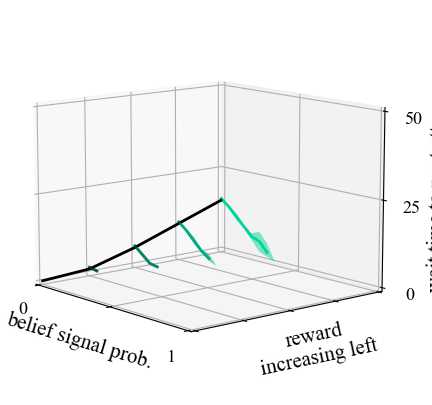

In [95]:
# imshow 3d
%matplotlib inline
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

vmin,vmax=0,50
nbin=20
bins=np.linspace(0,1,nbin)
plotdata=[] # for plot data

for food_reward_idx in range(len(food_reward_list))[1:]:
    bindata=[[] for _ in range(nbin)] 
    subdf=df[(df.trial_food_reward_idx==food_reward_idx)]
    sb, nextatt=[],[]
    for alist, b in zip(subdf.at_times, subdf.beliefs):
        try:
            a,b=trialnextatt(alist,b),trialsb(b)  
            for j in range(len(b)):
                thisa,thisb=a[j], b[j]
                for i, (s,e) in enumerate(zip(bins, bins[1:])):
                    if thisa>0 and s<thisb<=e:
                        bindata[i].append(thisa)
        except:
            continue

    mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
    mu, err=np.array(mu), np.array(err)
    med=np.array([np.nanmedian(a) for a in bindata])

    percentile_5 = np.array([np.percentile(data, 5) if data else 0 for data in bindata])
    percentile_95 = np.array([np.percentile(data, 95) if data else 0 for data in bindata])
    lowerr=np.clip(mu-percentile_5, 0,None)
    higherr=np.clip(percentile_95-mu, 0,None)

    plotdata.append([percentile_5, percentile_95, mu])

y_values = np.arange(len(food_reward_list)-2, -1,-1)
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='3d')
for y, (y1, y2, mu) in zip(y_values, plotdata):
    verts = []
    for i in range(len(bins) - 1):
        verts.append([(bins[i], y, y1[i]), (bins[i+1], y, y1[i+1]), (bins[i+1], y, y2[i+1]), (bins[i], y, y2[i])])
       
    poly = Poly3DCollection(verts, facecolors=rewardcmap(np.linspace(0, 1, len(food_reward_list)))[len(food_reward_list)-y-1], alpha=0.5, edgecolors='none')
    ax.add_collection3d(poly)
    # for i,(low,high) in enumerate(zip(y1,y2)):
    #     ax.plot([bins[i],bins[i]],[y,y], [low,high],color=rewardcmap(np.linspace(0, 1, len(food_reward_list)))[len(food_reward_list)-y-1], alpha=0.5)
    ax.plot(bins,np.zeros_like(bins)+y, mu,color=rewardcmap(np.linspace(0, 1, len(food_reward_list)))[len(food_reward_list)-y-1])
ax.plot(np.zeros_like(y_values),y_values,[low[0][0] for low in plotdata] ,color='black')

ax.set_xlim(0, 1)
ax.set_ylim(0, 2)
ax.set_zlim(0, 50)
ax.set_xlabel('belief signal prob.',labelpad=1)
ax.set_yticks([0,1,2,3,4],[])
ax.set_zticks([0,25,50])
ax.set_xticks([0,0.5,1],['0','','1'])
ax.set_ylabel('reward\nincreasing left',labelpad=1)
ax.set_zlabel('wait time to next attn.',labelpad=1)

plt.tight_layout()
ax.view_init(azim=-40, elev=11) 
quicksave('vary reward 3d p','plot wait time', fig=fig)
plt.show()


/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_30581/1263104828.py:26: RuntimeWarning: Mean of empty slice
  mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


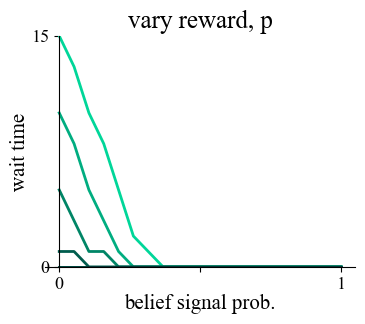

In [96]:
# imshow 2d lower tri
%matplotlib inline
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

vmin,vmax=0,50
nbin=20
bins=np.linspace(0,1,nbin)
plotdata=[] # for plot data
fig = plt.figure(figsize=(4,3))
ax = fig.add_subplot(111)
for food_reward_idx in range(len(food_reward_list))[:]:
    bindata=[[] for _ in range(nbin)] 
    subdf=df[(df.trial_food_reward_idx==food_reward_idx)]
    sb, nextatt=[],[]
    for alist, b in zip(subdf.at_times, subdf.beliefs):
        try:
            a,b=trialnextatt(alist,b),trialsb(b)  
            for j in range(len(b)):
                thisa,thisb=a[j], b[j]
                for i, (s,e) in enumerate(zip(bins, bins[1:])):
                    if thisa>0 and s<thisb<=e:
                        bindata[i].append(thisa)
        except:
            continue

    mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
    mu, err=np.array(mu), np.array(err)
    percentile_5 = np.array([np.percentile(data, 5) if data else 0 for data in bindata])
    ax.plot(bins, percentile_5,color=rewardcmap(np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])
    centerax(ax)
ax.set_ylim(0, 2)
ax.set_xlabel('belief signal prob.',labelpad=1)
ax.set_ylabel('wait time',labelpad=1)
ax.set_yticks([0,15])
ax.set_xticks([0,0.5,1],['0','','1'])
ax.set_title('vary reward, p')

quicksave('vary reward waittime np','plot wait time', fig=fig)
plt.show()